In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('data/phishing.csv')
df.shape

(11055, 31)

In [3]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [4]:
# Copy original data
df_fe = df.copy()

# New Feature 1: URL Suspicious Score
df_fe['URL_Suspicious_Score'] = (
    df_fe['having_IP_Address'] + 
    df_fe['URL_Length'] + 
    df_fe['Shortining_Service'] + 
    df_fe['having_At_Symbol'] + 
    df_fe['double_slash_redirecting']
)

print("Feature 1 Created Successfully!")
print(df_fe['URL_Suspicious_Score'].value_counts())

Feature 1 Created Successfully!
URL_Suspicious_Score
 3    5733
 1    2433
 5     949
-1     865
-3     777
-5     163
 4      45
 2      44
 0      23
-2      18
-4       5
Name: count, dtype: int64


In [5]:
# New Feature 2: Security Score
df_fe['Security_Score'] = (
    df_fe['SSLfinal_State'] + 
    df_fe['Domain_registeration_length'] + 
    df_fe['HTTPS_token'] + 
    df_fe['Favicon']
)

print("Feature 2 Created Successfully!")
print(df_fe['Security_Score'].value_counts())

Feature 2 Created Successfully!
Security_Score
 2    4825
 0    3148
 4    1096
-2     674
 1     550
 3     368
-1     225
-4     145
-3      24
Name: count, dtype: int64


In [6]:
# New Feature 3: Content Suspicious Score
df_fe['Content_Suspicious_Score'] = (
    df_fe['Request_URL'] + 
    df_fe['URL_of_Anchor'] + 
    df_fe['Links_in_tags'] + 
    df_fe['SFH'] + 
    df_fe['Submitting_to_email']
)

print("Feature 3 Created Successfully!")
print(df_fe['Content_Suspicious_Score'].value_counts())

Feature 3 Created Successfully!
Content_Suspicious_Score
 1    1910
 0    1857
-1    1725
-2    1609
 2    1399
 3     898
-3     893
 4     361
-4     195
-5     113
 5      95
Name: count, dtype: int64


In [7]:
# New Feature 4: Domain Suspicious Score
df_fe['Domain_Suspicious_Score'] = (
    df_fe['having_Sub_Domain'] + 
    df_fe['Domain_registeration_length'] + 
    df_fe['Abnormal_URL'] + 
    df_fe['DNSRecord'] + 
    df_fe['web_traffic']
)

print("Feature 4 Created Successfully!")
print(df_fe['Domain_Suspicious_Score'].value_counts())

Feature 4 Created Successfully!
Domain_Suspicious_Score
 1    2355
 3    2125
 2    1981
 0    1351
-1    1115
-2     659
-3     488
 4     450
 5     408
-4     106
-5      17
Name: count, dtype: int64


In [8]:
# New Feature 5: Total Phishing Score
df_fe['Total_Phishing_Score'] = (
    df_fe['URL_Suspicious_Score'] + 
    df_fe['Security_Score'] + 
    df_fe['Content_Suspicious_Score'] + 
    df_fe['Domain_Suspicious_Score']
)

print("Feature 5 Created Successfully!")
print(df_fe['Total_Phishing_Score'].value_counts())

Feature 5 Created Successfully!
Total_Phishing_Score
 7     994
 5     966
 4     899
 6     893
 8     804
 3     756
 9     750
 2     652
 1     554
 10    536
 0     464
 11    427
-1     415
-2     309
-3     296
-4     231
 12    230
-5     200
 13    147
-6      89
-7      85
 14     59
-9      46
-8      44
-10     37
-11     34
-12     33
 15     28
-13     24
-14     22
 16     13
-15     12
-16      3
 17      2
-17      1
Name: count, dtype: int64


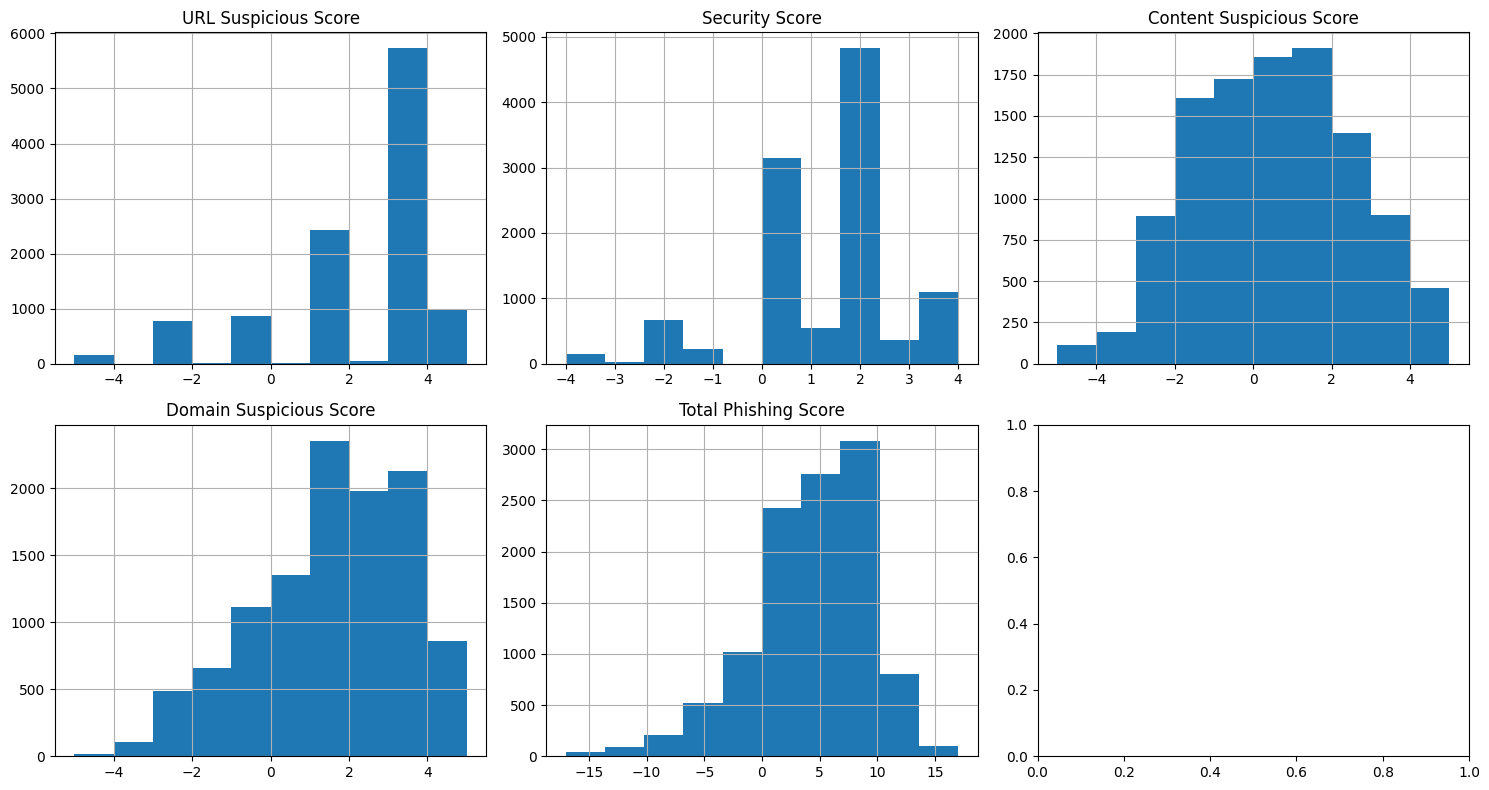

In [9]:
# Plot new features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

df_fe['URL_Suspicious_Score'].hist(ax=axes[0,0])
axes[0,0].set_title('URL Suspicious Score')

df_fe['Security_Score'].hist(ax=axes[0,1])
axes[0,1].set_title('Security Score')

df_fe['Content_Suspicious_Score'].hist(ax=axes[0,2])
axes[0,2].set_title('Content Suspicious Score')

df_fe['Domain_Suspicious_Score'].hist(ax=axes[1,0])
axes[1,0].set_title('Domain Suspicious Score')

df_fe['Total_Phishing_Score'].hist(ax=axes[1,1])
axes[1,1].set_title('Total Phishing Score')

plt.tight_layout()
plt.show()

In [10]:
# Save new dataset
df_fe.to_csv('data/phishing_featured.csv', index=False)

print("Feature Engineering Complete!")
print(f"Old Shape: {df.shape}")
print(f"New Shape: {df_fe.shape}")
print(f"New Features Added: {df_fe.shape[1] - df.shape[1]}")

Feature Engineering Complete!
Old Shape: (11055, 31)
New Shape: (11055, 36)
New Features Added: 5


In [11]:
# Check correlation of new features with target
new_features = ['URL_Suspicious_Score', 'Security_Score', 
                'Content_Suspicious_Score', 'Domain_Suspicious_Score',
                'Total_Phishing_Score']

correlation = df_fe[new_features + ['Result']].corr()['Result']
print("Correlation of New Features with Target:")
print(correlation.sort_values(ascending=False))

Correlation of New Features with Target:
Result                      1.000000
Content_Suspicious_Score    0.547983
Total_Phishing_Score        0.389811
Security_Score              0.249597
Domain_Suspicious_Score     0.173384
URL_Suspicious_Score        0.045674
Name: Result, dtype: float64
